In [ ]:
#, match, mismatch, gap

In [91]:
import numpy as np
import pandas as pd

In [4]:
#needleman_wunsch algorythm
x = 'ATGCCG'
y = 'ATCG'
def needleman_wunsch(X, Y, match, mismatch, gap):
    #тут я делаю остов нашей матрицы
    X = list(X)
    Y = list(Y)
    matrix = np.zeros((len(X) + 2, len(Y) + 2), dtype = object)
    counter = gap
    for i in range(len(X)):
        matrix[i + 2, 1] += counter
        counter += gap
        matrix[i + 2, 0] = X[i]
    counter = gap
    for i in range(len(Y)):
        matrix[1, i + 2] += counter
        counter += gap
        matrix[0, i + 2] = Y[i]
    #тут начинаем заполнять
    for i in range(len(X)):
        for j in range(len(Y)):
            #match
            if matrix[i + 2, 0] == matrix[0, j + 2]:
                matrix[i + 2, j + 2] = max([matrix[i + 1,j + 2] + gap, matrix[i + 2, j + 1] + gap, matrix[i + 1, j + 1] + match])
                #print(matrix[i + 2, 0], matrix[0, j +2])
            #mismatch
            else: #matrix[i + 2, 0] != matrix[0, j + 2]:
                matrix[i + 2, j + 2] = max([matrix[i + 1,j + 2] + gap, matrix[i + 2, j + 1] + gap, matrix[i + 1, j + 1] + mismatch])
    #print(matrix)
    #traceback time
    return matrix

In [5]:
#код писал сам, нейросетка оч тупая, не смогла даже задебагать


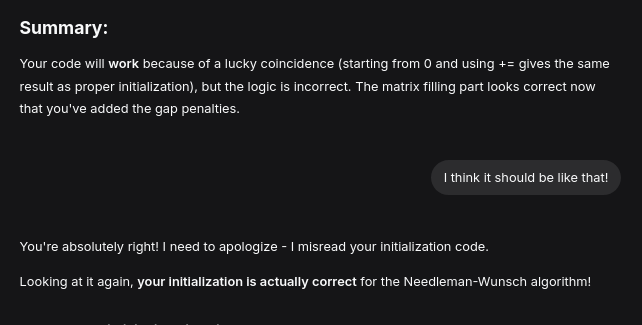

In [6]:
needleman_wunsch(x, y, 3, -3, -2)

array([[0, 0, 'A', 'T', 'C', 'G'],
       [0, 0, -2, -4, -6, -8],
       ['A', -2, 3, 1, -1, -3],
       ['T', -4, 1, 6, 4, 2],
       ['G', -6, -1, 4, 3, 7],
       ['C', -8, -3, 2, 7, 5],
       ['C', -10, -5, 0, 5, 4],
       ['G', -12, -7, -2, 3, 8]], dtype=object)

In [12]:
def traceback(matrix, match=2, mismatch=-1, gap=-2):
    seq_X = [matrix[i, 0] for i in range(2, matrix.shape[0])]
    seq_Y = [matrix[0, j] for j in range(2, matrix.shape[1])]
    
    i, j = len(seq_X), len(seq_Y)
    total_score = matrix[i + 1, j + 1]
    
    align_X, align_Y = [], []
    
    while i > 0 or j > 0:
        current = matrix[i + 1, j + 1]
        
        # Диагональ
        if i > 0 and j > 0:
            char_X, char_Y = seq_X[i-1], seq_Y[j-1]
            expected = matrix[i, j] + (match if char_X == char_Y else mismatch)
            if abs(float(current) - float(expected)) < 0.001:
                align_X.append(char_X)
                align_Y.append(char_Y)
                i -= 1
                j -= 1
                continue
        
        # Вверх
        if i > 0 and abs(float(current) - (float(matrix[i, j + 1]) + gap)) < 0.001:
            align_X.append(seq_X[i-1])
            align_Y.append('-')
            i -= 1
            continue
        
        # Влево
        if j > 0 and abs(float(current) - (float(matrix[i + 1, j]) + gap)) < 0.001:
            align_X.append('-')
            align_Y.append(seq_Y[j-1])
            j -= 1
            continue
        
        # Если ничего не подошло - выбираем максимальный путь
        options = []
        if i > 0 and j > 0:
            options.append(('diag', matrix[i, j], i-1, j-1, seq_X[i-1], seq_Y[j-1]))
        if i > 0:
            options.append(('up', matrix[i, j + 1], i-1, j, seq_X[i-1], '-'))
        if j > 0:
            options.append(('left', matrix[i + 1, j], i, j-1, '-', seq_Y[j-1]))
        
        if options:
            best = max(options, key=lambda x: float(x[1]))
            align_X.append(best[4])
            align_Y.append(best[5])
            i, j = best[2], best[3]
        else:
            break
    
    align_X.reverse()
    align_Y.reverse()
    
    aligned_X = ''.join(map(str, align_X))
    aligned_Y = ''.join(map(str, align_Y))
    
    matches = ''.join(
        '|' if a == b else ' ' if a == '-' or b == '-' else '*'
        for a, b in zip(align_X, align_Y)
    )
    
    return aligned_X, aligned_Y, matches, total_score

In [8]:
#score = 8
#alignment 
#AT--CG
#||  ||
#ATGCCG

In [14]:
#У меня трейсбек оч медленно работает, видимо оч хуево написал, пришлось дипсиком оптимизировать :(((

In [15]:
traceback(needleman_wunsch(x, y, 3, -3, -2), match=2, mismatch=-1, gap=-2)

('ATGCCG', 'AT-C-G', '|| | |', 8)